# SPI--SPI geometry of 1,053 heterogeneous MTS datasets

Every dataset is shown neutrally. Primary cluster models are fitted in PCA space.
The final exploration section also reproduces the historical 2-D clustering as a
descriptive comparison. Grey density contours guide inspection; interpretation
and dynamical naming are post hoc.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.atlas_analysis import cluster_medoids
from src.corpus_geometry import nearest_neighbour_table
from src.corpus_visualization import (
    interactive_embedding_browser,
    plot_embedding,
    plot_mts_heatmap,
)

from scripts.explore_zenodo_geometry import paper_style, map_axis
paper_style()  # docs/benchmark-figure-style.md: serif, compact, unboxed, no grid
GEOMETRY = ROOT / 'results' / 'corpus_geometry'
ATLAS = ROOT / 'results' / 'zenodo_7118947' / 'atlas-seed1729'
comparison = pd.read_csv(GEOMETRY / 'geometry-comparison.csv')
comparison[(comparison.study == 'zenodo_1053') & comparison.retained_features.notna()][
    ['recipe', 'retained_reference_rows', 'retained_features', 'pca_cumulative_variance']
]

,recipe,retained_reference_rows,retained_features,pca_cumulative_variance
10,legacy,1023.0,24938.0,0.609992
11,center,1053.0,21788.0,0.725223
12,standard,1053.0,21788.0,0.664491
13,robust,1053.0,21788.0,0.999331


The historical rule excludes 30 complete datasets solely because their feature
validity falls below its row threshold. The fitted recipes retain all 1,053.
Scaling changes the geometry. Centre-only remains a working primary view, with
standardized PCA retained as a sensitivity analysis; proof-data retrieval is not
evidence that the same choice is universally optimal on this heterogeneous corpus.

In [2]:
with np.load(ATLAS / 'atlas-results.npz', allow_pickle=True) as archive:
    atlas = {key: archive[key] for key in archive.files}
summary = json.loads(atlas['summary_json'].item())
cluster_summary = pd.DataFrame([
    {'method': 'K-means', 'selected': f"k={int(atlas['kmeans_clusters'])}",
     'validated': True,
     'stability': summary['primary_kmeans']['subsample_stability']},
    {'method': 'GMM', 'selected': f"k={int(atlas['gmm_components'])}",
     'validated': bool(atlas['gmm_validated']),
     'stability': summary['diagnostic_gmm']['subsample_stability']},
    {'method': 'HDBSCAN', 'selected': f"k={len(set(atlas['hdbscan_labels'])) - (int(-1 in atlas['hdbscan_labels']))}",
     'validated': bool(atlas['hdbscan_validated']),
     'stability': summary['primary_hdbscan_subsample_stability']},
])
cluster_summary

,method,selected,validated,stability
0,K-means,k=8,True,0.955311
1,GMM,k=13,False,0.587279
2,HDBSCAN,k=2,False,0.511321


The stable K-means partition is a useful resolution of this representation, not a claim that the corpus has exactly eight natural dynamical classes. The fitted GMM and HDBSCAN views fail the prespecified stability threshold and remain diagnostics.

In [3]:
views = [
    ('PCA', atlas['pca_scores'][:, :2]),
    ('UMAP', atlas['umap']),
    ('t-SNE', atlas['tsne']),
]
fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.25), constrained_layout=True)
for ax, (name, coordinates) in zip(axes, views):
    map_axis(ax, coordinates, atlas['kmeans_labels'], title=name, axes_name=name)
fig.suptitle('All 1,053 datasets; projected K-means density contours in grey', y=1.04)
plt.show()

/var/folders/nq/8y70t4y10yb6nq4v5m7p_j340000gp/T/ipykernel_31814/544979714.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Historical distance-matrix recipe (not the old t-SNE preprocessing)

The adapter for `old/compute_distance_matrix.py` standardizes features, filters
at 90% feature / 80% row validity, fills missing standardized values with zero,
and uses Euclidean distance. Its PCA view contains 1,023 datasets. It omits the
old catalogue-specific exclusion lists and is not a full historical reproduction.
The actual Figure 4--5 t-SNE preprocessing is reproduced in the final subsection.

In [4]:
with np.load(GEOMETRY / 'zenodo_1053' / 'legacy.npz', allow_pickle=True) as archive:
    legacy = {key: archive[key] for key in archive.files}
fig, ax = plot_embedding(legacy['query_pca'][:, :2], title='Historical preprocessing',
                         xlabel='PC1', ylabel='PC2')
plt.show()

/var/folders/nq/8y70t4y10yb6nq4v5m7p_j340000gp/T/ipykernel_31814/3128930202.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## GMM diagnostic view

In [5]:
from matplotlib.patches import Ellipse

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.15), constrained_layout=True)
coordinates = atlas['pca_scores'][:, :2]
axes[0].scatter(coordinates[:, 0], coordinates[:, 1], s=7, c='.15', alpha=.6, linewidth=0)
for mean, covariance in zip(atlas['gmm_means'], atlas['gmm_covariances']):
    cov2 = covariance[:2, :2]
    eigval, eigvec = np.linalg.eigh(cov2)
    order = np.argsort(eigval)[::-1]
    eigval, eigvec = eigval[order], eigvec[:, order]
    angle = np.degrees(np.arctan2(eigvec[1, 0], eigvec[0, 0]))
    axes[0].add_patch(Ellipse(mean[:2], *(2 * np.sqrt(5.991 * np.maximum(eigval, 0))),
                              angle=angle, fc='.55', ec='.25', alpha=.10, lw=.7))
axes[0].set(title='Projected 95% component ellipses', xlabel='PC1', ylabel='PC2')

grid = pd.read_csv(ATLAS / 'cluster-model-grid.csv')
gmm = grid[grid.method == 'gmm'].copy()
for (dimension, covariance), group in gmm.groupby(['dimensions', 'covariance_type']):
    if dimension == int(atlas['gmm_dimension']):
        group = group.sort_values('clusters')
        axes[1].plot(group.clusters, group.bic - group.bic.min(), marker='o', ms=2.5,
                     lw=.9, label=covariance)
axes[1].set(title=f"BIC at PCA{int(atlas['gmm_dimension'])}", xlabel='Components', ylabel=r'$\Delta$BIC')
axes[1].legend(frameon=False, fontsize=7)

probability = atlas['gmm_probability']
entropy = -np.sum(probability * np.log(probability + 1e-15), axis=1) / np.log(probability.shape[1])
axes[2].hist(entropy, bins=25, color='.25', edgecolor='white', lw=.3)
axes[2].set(title='Assignment uncertainty', xlabel='Normalized posterior entropy', ylabel='Datasets')
plt.show()

/var/folders/nq/8y70t4y10yb6nq4v5m7p_j340000gp/T/ipykernel_31814/4225802930.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


The Gaussian mixture is useful for showing soft assignments and covariance geometry. Its low resampling stability means the 13-component solution should not be promoted to a corpus taxonomy.

## Raw-MTS heatmap scaling

In [6]:
DATABASE = ROOT / 'data' / 'zenodo_7118947' / 'database.npz'
examples = [
    'noise_cauchy_M5_T100',
    'wave-2D_M-25_T-1000',
    'mousefMRI_S-0_R-23-24',
    'epidemic_incidence_C40-54',
]
methods = [('legacy', 'Old cross-process robust'),
           ('zscore', 'Per-process z-score'),
           ('robust', 'Per-process robust')]
with np.load(DATABASE, allow_pickle=False) as database:
    fig, axes = plt.subplots(len(examples), len(methods), figsize=(11, 8), constrained_layout=True)
    for row, dataset in enumerate(examples):
        for col, (method, label) in enumerate(methods):
            plot_mts_heatmap(database[dataset], method=method, ax=axes[row, col],
                             title=(label if row == 0 else None))
            if col == 0:
                axes[row, col].set_ylabel(dataset + '\nProcess', fontsize=7)
plt.show()

/var/folders/nq/8y70t4y10yb6nq4v5m7p_j340000gp/T/ipykernel_31814/1170688103.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


The adopted display is per-process robust scaling: subtract the temporal median
and divide by $\mathrm{IQR}/1.349$, then clip symmetrically at the within-MTS 99th
percentile of absolute scaled values. The alternatives above show what changes.
This display transform does not modify the SPI feature bank. PNG serves previews;
SVG with an embedded raster keeps the MTS panels small and usable in figure editors.

## Feature matrix and nearest-neighbour retrieval

In [7]:
from IPython.display import Markdown, display
display(Markdown('[Open the full $1053\times41616$ feature matrix]('
                 '../../results/zenodo_7118947/atlas-seed1729/figures/atlas-full-feature-matrix.png)'))

medoids = cluster_medoids(atlas['pca_scores'][:, :int(atlas['kmeans_dimension'])], atlas['kmeans_labels'])
rows = []
for cluster, index in sorted(medoids.items())[:4]:
    focal = str(atlas['dataset'][index])
    for rank, (dataset, distance) in enumerate(nearest_neighbour_table(
            atlas['pca_scores'][:, :int(atlas['kmeans_dimension'])], atlas['dataset'], focal, k=5), 1):
        rows.append({'cluster': cluster, 'focal': focal, 'rank': rank,
                     'neighbour': dataset, 'distance': distance})
pd.DataFrame(rows)

[Open the full $1053	imes41616$ feature matrix](../../results/zenodo_7118947/atlas-seed1729/figures/atlas-full-feature-matrix.png)

,cluster,focal,rank,neighbour,distance
0,0,FaceDetection_C-1_I-5,1,FaceDetection_C-1_I-2,8.844632
1,0,FaceDetection_C-1_I-5,2,FaceDetection_C-0_I-9,10.374699
2,0,FaceDetection_C-1_I-5,3,FaceDetection_C-1_I-6,12.442405
3,0,FaceDetection_C-1_I-5,4,FaceDetection_C-1_I-4,12.928550
4,0,FaceDetection_C-1_I-5,5,FaceDetection_C-1_I-3,12.934503
5,1,kuramoto-sakaguchi_conn-neighbour_M-16_T-100,1,kuramoto-sakaguchi_conn-neighbour_M-25_T-100,7.011882
6,1,kuramoto-sakaguchi_conn-neighbour_M-16_T-100,2,kuramoto-sakaguchi_conn-rand_M-16_T-500,7.271464
7,1,kuramoto-sakaguchi_conn-neighbour_M-16_T-100,3,kuramoto-sakaguchi_conn-neighbour_M-16_T-500,7.680843
8,1,kuramoto-sakaguchi_conn-neighbour_M-16_T-100,4,kuramoto-sakaguchi_conn-rand_M-25_T-100,7.826638
9,1,kuramoto-sakaguchi_conn-neighbour_M-16_T-100,5,kuramoto-sakaguchi_conn-rand_M-9_T-100,8.180800


Nearest neighbours are direct retrievals in the fitted PCA geometry. The focal datasets above are algorithmic medoids, not manually selected exemplars.

## Live point-to-MTS browser

In [8]:
# Call launch_browser() in a live kernel. It is deliberately not executed here:
# serializing a Plotly FigureWidget adds about 5 MB of widget state and callbacks
# are inactive in static PDF/HTML exports.
def launch_browser():
    database = np.load(DATABASE, allow_pickle=False)
    return interactive_embedding_browser(
        atlas['umap'],
        atlas['dataset'],
        lambda name: database[name],
        title='Click a dataset to inspect its raw MTS',
        scaling='robust',
    )

print('Run launch_browser() in a live kernel to activate point-to-MTS selection.')

Run launch_browser() in a live kernel to activate point-to-MTS selection.


## Figures 4--5: historical method and visual sensitivity

The draft's Figure 4 is a corpus map with selected examples; Figure 5 collects
members of selected groups. Its original SPI similarity is Spearman-based.
Here every experiment uses our existing Pearson bank, $X\in\mathbb{R}^{1053\times41616}$,
with 289 SPIs and one correlation of aligned ordered off-diagonal entries per SPI pair.
Undefined features remain NaN in the canonical NPZ; no new pyspi computation is needed.

**Historical downstream recipe:** remove duplicate feature columns, retain rows
with at least 20% observed features, then columns with at least 80% observed rows;
fill raw NaNs with zero; direct t-SNE ($p=10$, seed 42, PCA initialization,
automatic learning rate, 1,000 iterations); contrib HDBSCAN with minimum cluster
size 5 and minimum samples 5. Defaults come from the available `CorrelationFrame`
implementation; the original execution environment/feature bank is unavailable.
The control panels isolate adding PCA50 and changing preprocessing.

**Current alternatives:** 95%-valid varying features, median imputation and
centering, covariance PCA at $d\in\{20,50,100\}$, followed by t-SNE at
$p\in\{10,30,50\}$ or UMAP at $n\in\{15,30,60\}$ (Euclidean, minimum distance 0.1).
Additional panels vary standardization, minimum distance and random seed.
PCA50, t-SNE $p=30$ and UMAP $n=30$ are moderate starting points for inspection,
not established optima. Truncation and small neighbourhoods can hide or split structure.

K-means ($k=8,20,40,60$), diagonal GMM ($k=8,20,40$, PCA20), and HDBSCAN EOM/leaf
partitions explore broad and fine resolutions in PCA space. Separate map partitions
repeat HDBSCAN in 2-D. Grey KDE mass contours (50%/80%) are visual summaries, not
confidence regions. All points, including noise, remain visible. Cluster names are yours
to assign after inspection; a visually attractive separation is not validation.

**Observed:** the historical adaptation yields 45 clusters and 138 noise rows.
PCA50 + t-SNE $p=30$ is a useful first inspection view: full-feature neighbour
recall is 0.492 versus 0.494 for PCA100, so this metric gives little reason to
prefer the larger input. For UMAP, $n=15$ preserves more local neighbours than
$n=30$ or $60$ here; PCA100/$n=15$ reaches 0.425. For a finer PCA-space partition,
K-means PCA20/$k=20$ has conditional resampling ARI 0.832; PCA20/$k=40$ falls to
0.720. These are exploratory comparisons, not a validation of 20 natural classes.

[t-SNE guidance](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
supports PCA pre-reduction; [UMAP guidance](https://umap-learn.readthedocs.io/en/latest/clustering.html)
warns that 2-D embeddings can introduce false separations. Cluster quality is assessed in
the fitted space. BIC compares only the GMMs fitted to the same PCA20 representation.

[Open offline cluster inspection and SVG/PNG exports](file:///Users/wedi0306/Code/mts-spi-study-cluster/results/zenodo_7118947/visual-exploration/index.html)

,dimensions,variance_explained,full_feature_knn15
0,20,0.613,0.620
1,50,0.725,0.716
2,100,0.805,0.792


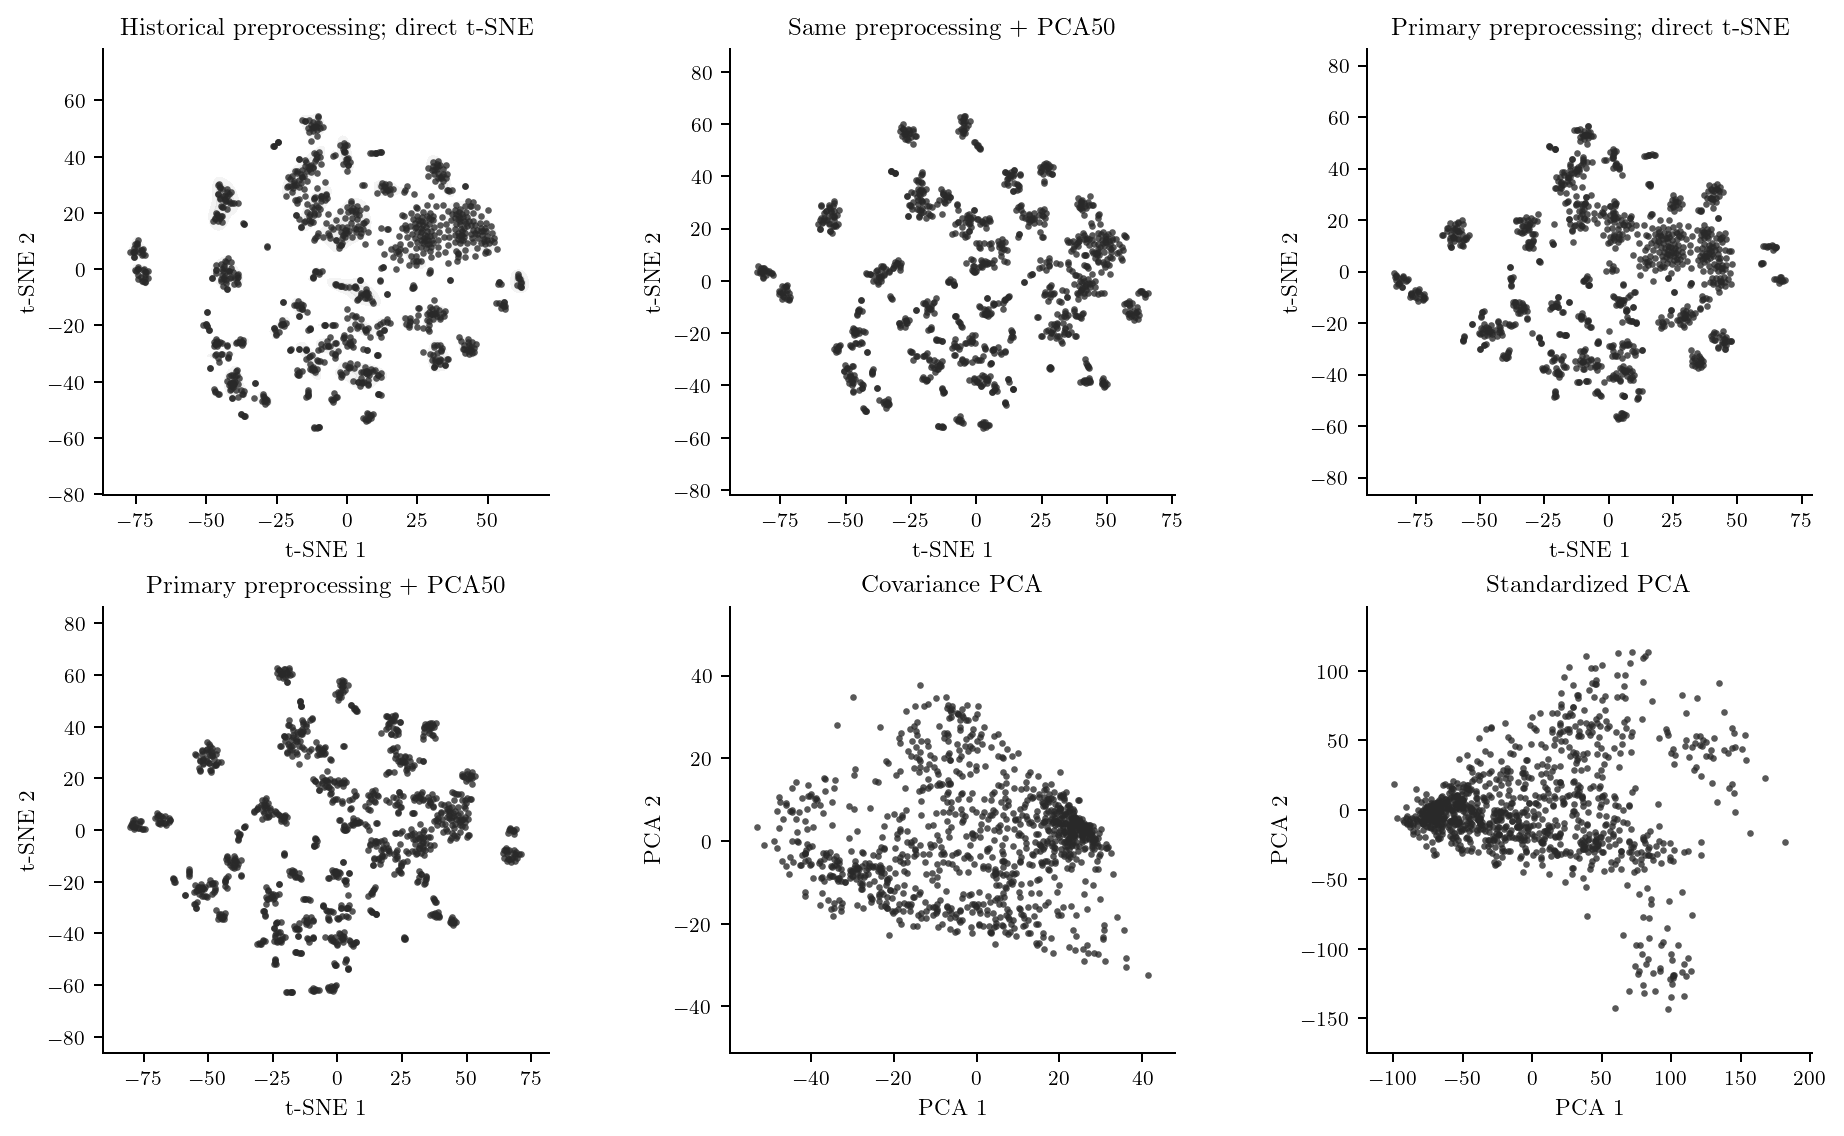

In [9]:
from IPython.display import Image, Markdown, display
EXPLORE = ROOT / 'results/zenodo_7118947/visual-exploration'
display(Markdown(f'[Open offline cluster inspection and SVG/PNG exports]({(EXPLORE / "index.html").as_uri()})'))
display(pd.read_csv(EXPLORE / 'pca-sensitivity.csv').round(3))
display(Image(filename=str(EXPLORE / 'figures/historical-controls.png')))

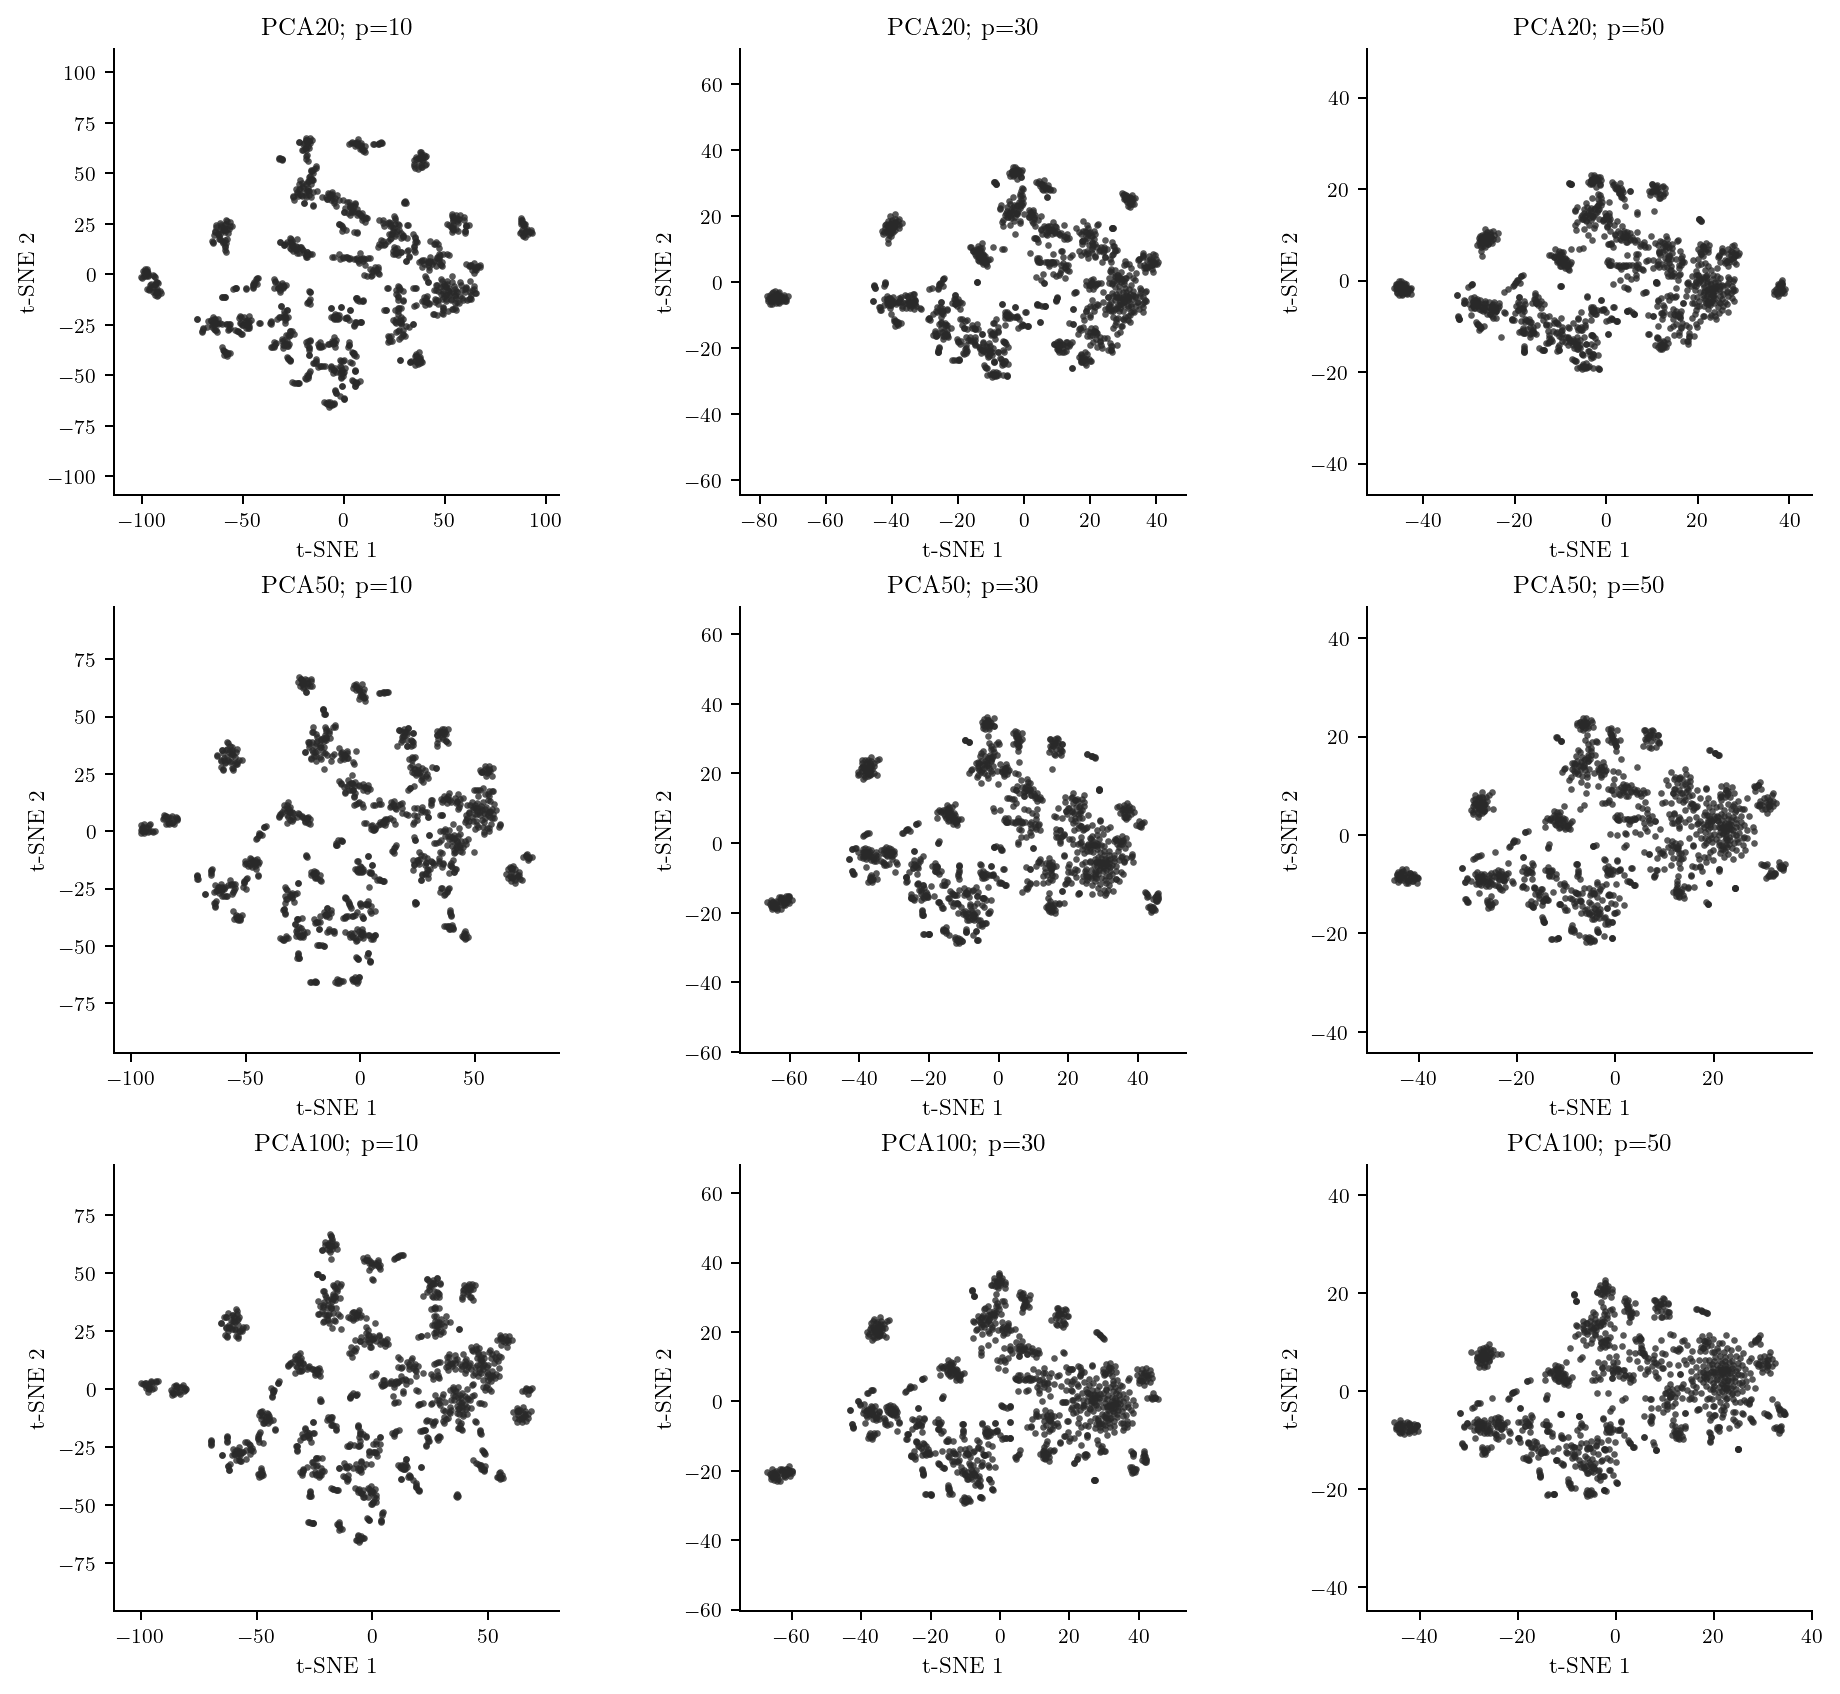

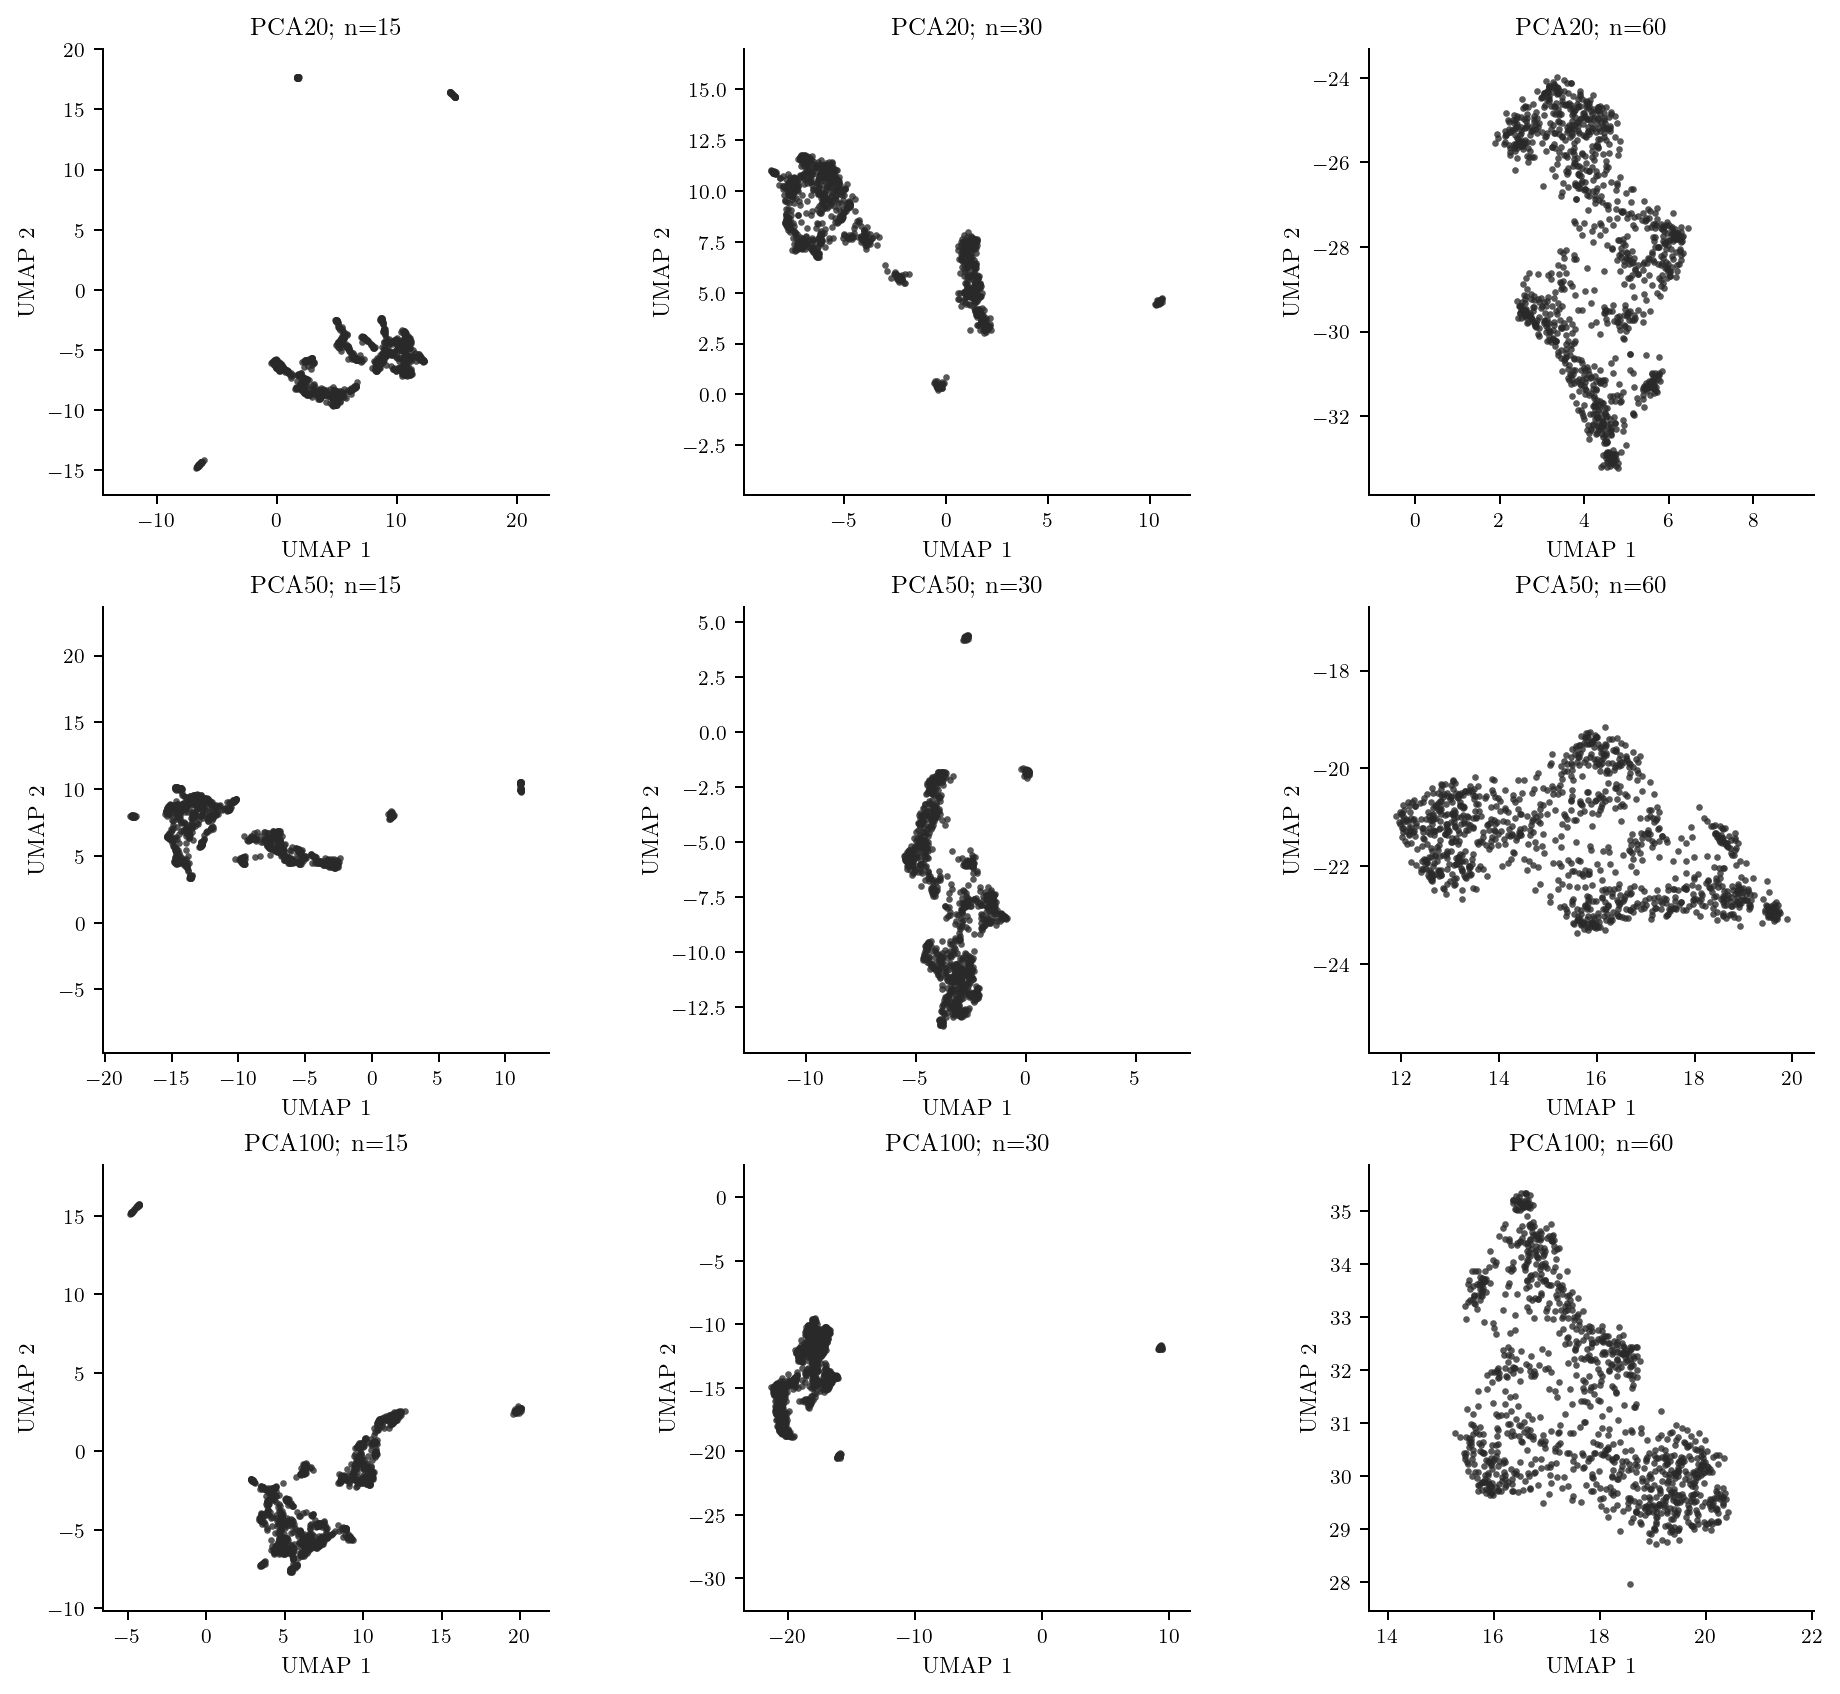

In [10]:
display(Image(filename=str(EXPLORE / 'figures/tsne-sensitivity.png')))
display(Image(filename=str(EXPLORE / 'figures/umap-sensitivity.png')))

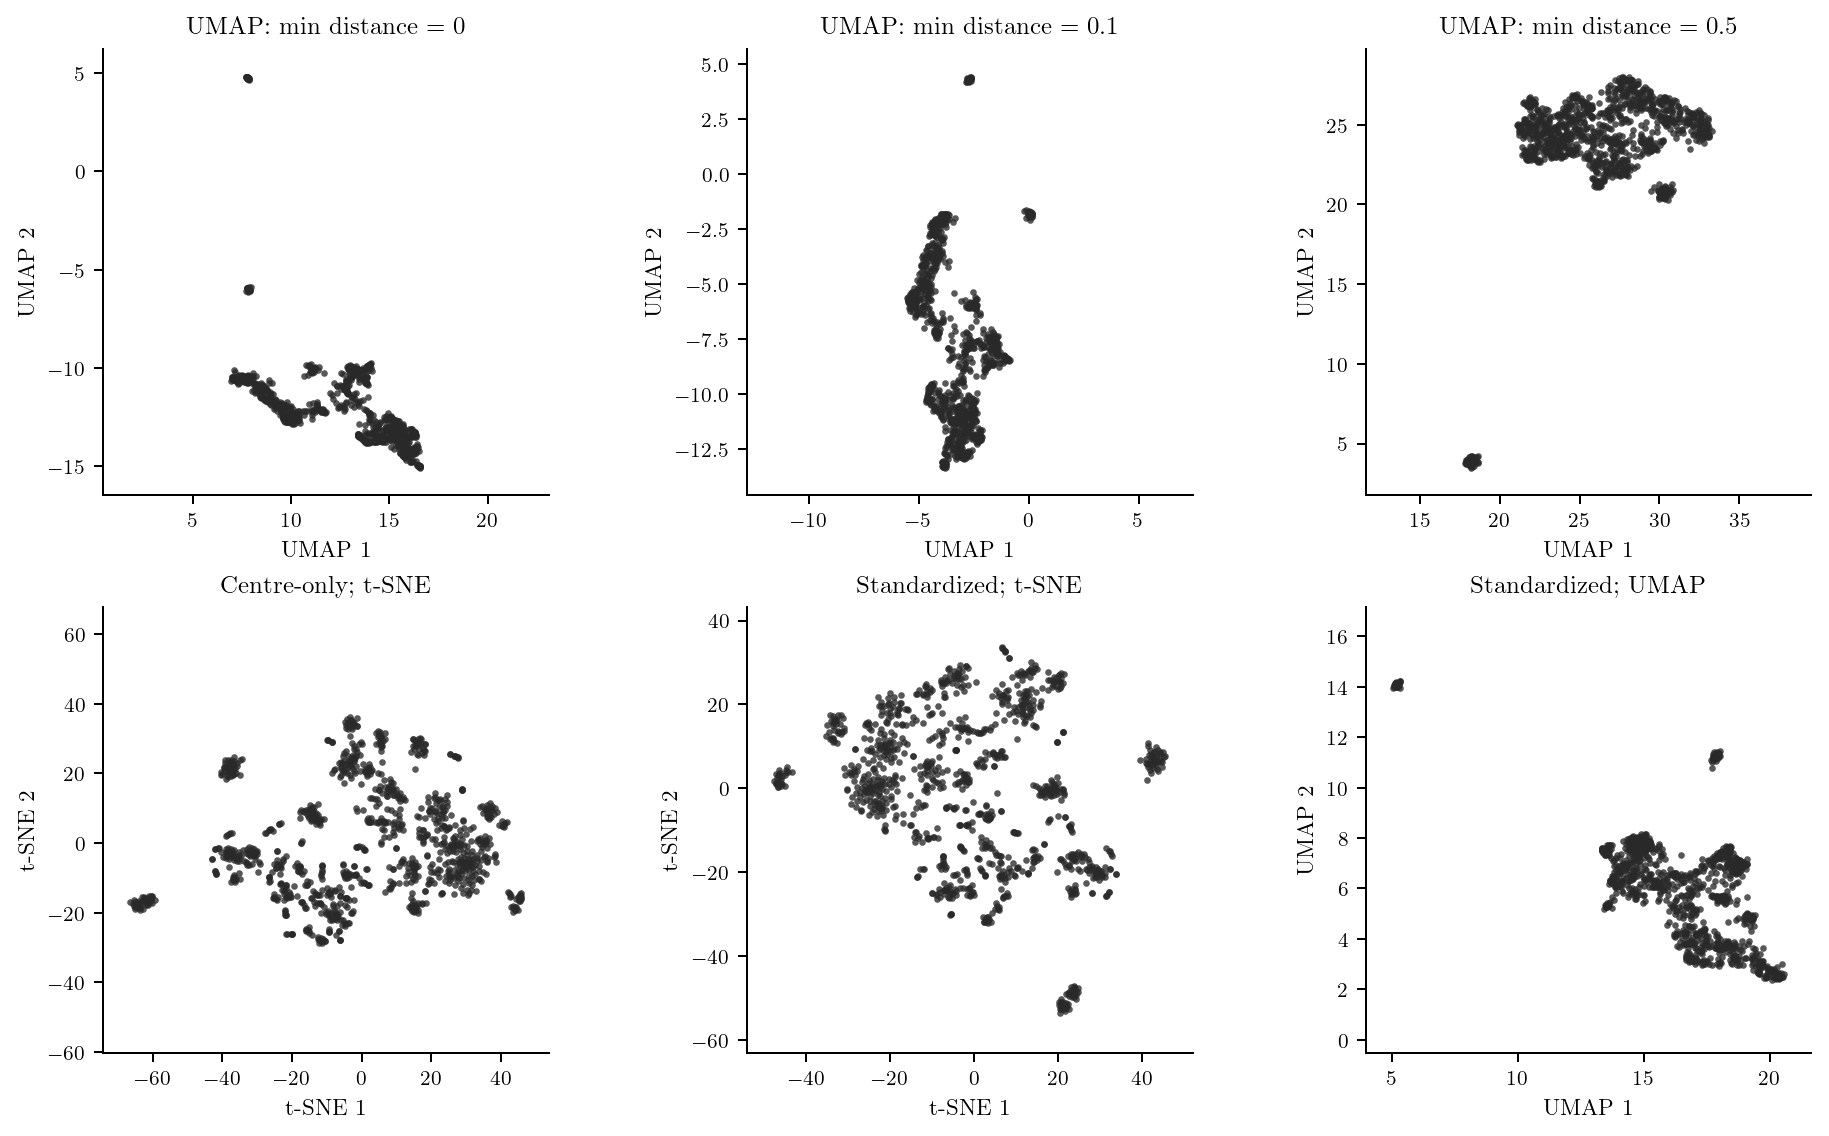

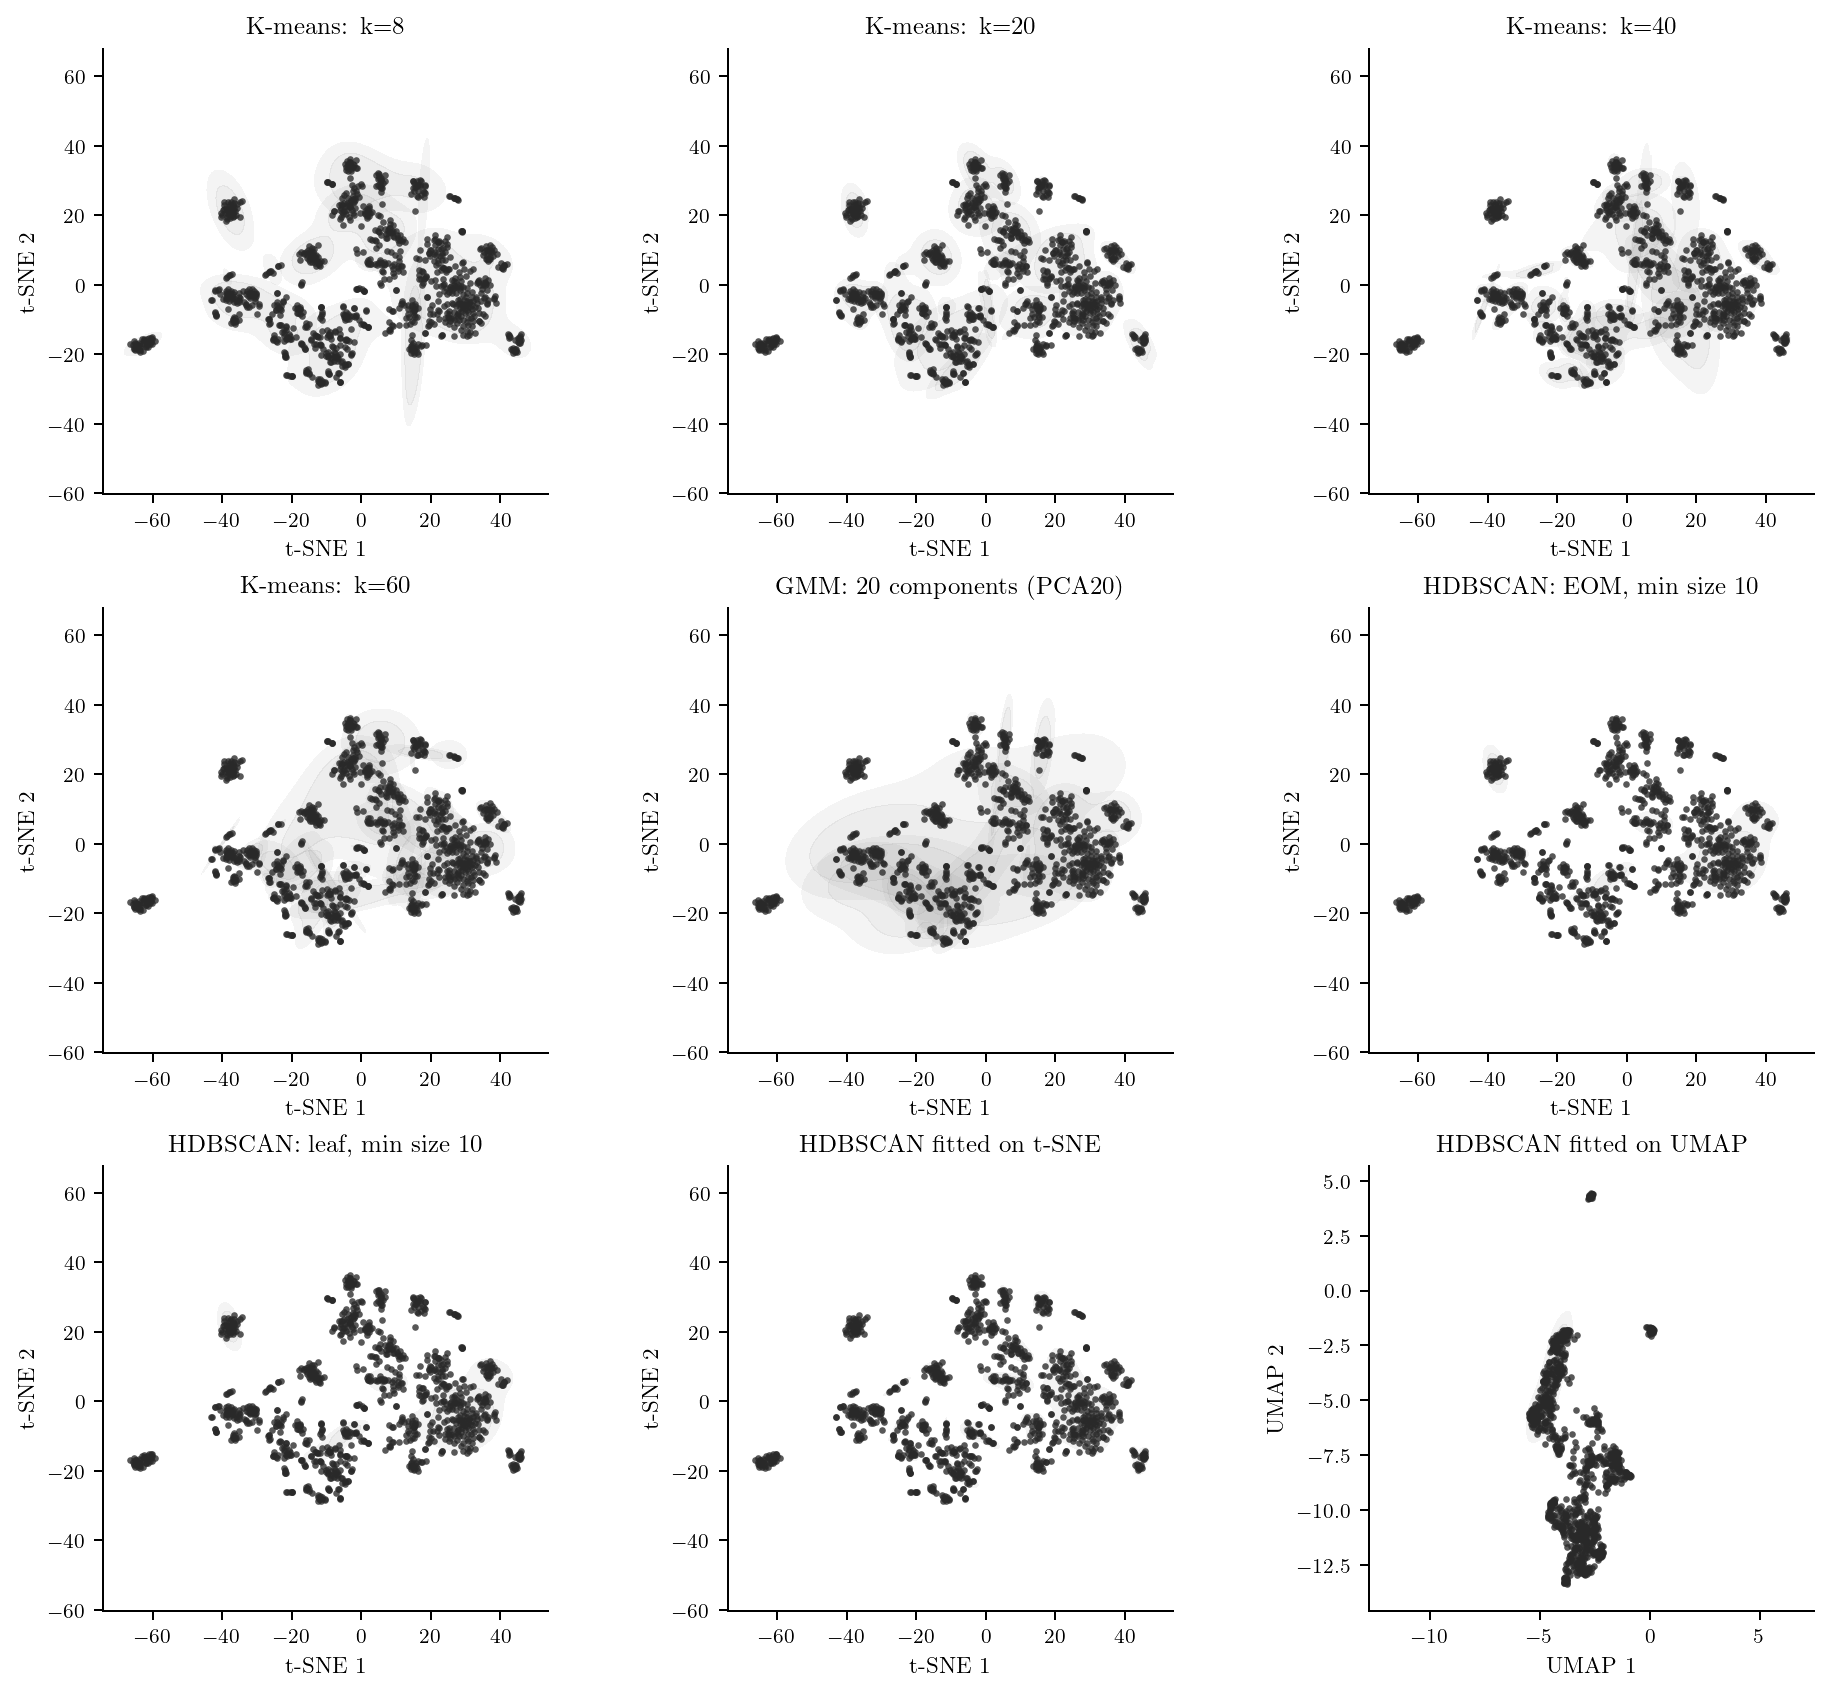

,partition,space,clusters,coverage,median_size,subsample_ARI
0,map-historical,historical (2D descriptive),45,0.869,12.0,NaN
1,map-tsne-pca50-p30,tsne-pca50-p30 (2D descriptive),39,0.877,16.0,NaN
4,kmeans-pca20-k20,PCA20,20,1.000,46.0,0.832
5,kmeans-pca20-k40,PCA20,40,1.000,25.0,0.720
8,kmeans-pca50-k20,PCA50,20,1.000,46.5,0.765
10,kmeans-pca50-k60,PCA50,60,1.000,15.0,0.680
16,gmm-pca20-k20,PCA20,20,1.000,43.5,0.607
21,hdbscan-pca50-leaf-m10,PCA50,12,0.380,16.0,NaN


In [11]:
display(Image(filename=str(EXPLORE / 'figures/scaling-and-spacing.png')))
display(Image(filename=str(EXPLORE / 'figures/cluster-resolutions.png')))
metrics = pd.read_csv(EXPLORE / 'cluster-metrics.csv')
selected = ['map-historical', 'map-tsne-pca50-p30', 'kmeans-pca20-k20',
            'kmeans-pca20-k40', 'kmeans-pca50-k20', 'kmeans-pca50-k60',
            'gmm-pca20-k20', 'hdbscan-pca50-leaf-m10']
display(metrics[metrics.partition.isin(selected)][
    ['partition', 'space', 'clusters', 'coverage', 'median_size', 'subsample_ARI']].round(3))

Full numeric outputs: `exploration.npz` (coordinates, PCA scores, partitions),
`memberships.csv` (every dataset in every partition), `medoids.csv` (actual members
minimizing total within-cluster distance), and metric CSVs. The offline gallery allows
point/cluster selection, name filtering, raw-MTS inspection and CSV export of manually
labelled subsets. Heatmap filenames map to dataset names in `heatmap-index.csv`.

The canonical feature bank is local at
`data/zenodo_7118947/features/pearson-unified-v3-seed1729.npz` (`X`, validity mask,
SPI-pair schema, metadata/provenance); raw MTS are in `data/zenodo_7118947/database.npz`.
The recorded Gadi mirror is `/g/data/ql44/we2614/mts-spi-data/zenodo_7118947/`.
The raw matrix occupies 167 MiB as float32; local analysis suffices.
Run `.venv/bin/python -m scripts.explore_zenodo_geometry` to reproduce, or append
`--figures-only` to render cached results. The script requires `hdbscan==0.8.44`.

### Higher resolution and reviewed groups

Added $k=80,120,160,200$ on PCA20/50/100, preserving existing embeddings and
partition IDs. The historical map also has HDBSCAN leaf/minimum-size-5/10 variants.
The old code's active method was HDBSCAN size 5; its optional K-medoids branch
fixed $k=200$ in the 2-D map. Our high-$k$ comparison uses K-means in PCA space.

For browsing, start at **PCA100/$k=80$**, then compare PCA50/$k=80$ and $120$.
At $k=80$, median cluster size is 10 and approximately 4% of rows lie in groups
smaller than five; at $k=200$, median size is 4 and roughly a quarter lie in such
small groups. Higher $k$ therefore adds fragmentation as well as useful specificity.
PCA dimension also matters: PCA100/$k=80$ isolates all ten walking recordings,
whereas some higher-$k$ PCA20 partitions still mix walking with other activities.

The shortlist shows **all members** of each selected group. Homogeneous/heterogeneous
describe whether the explicitly listed classes are the same/different; real/synthetic/mixed
describe origin separately. Neither axis establishes dynamical coherence. Titles describe
source composition, not inferred mechanisms. Group-level Jaccard matches across five
80% subsamples supplement global ARI; PCA remains fixed. A complete-feature
sensitivity uses the 9,313 varying features observed in every MTS, requiring no
imputation. The mixed financial/Brownian/fMRI group is explicitly provisional.
The report also shows measured dynamics and nearest excluded records. An exact
prefix check finds the excluded M16/T100 wave record inside longer included wave
records: that boundary reflects observation/estimation effects, not a different
underlying system. Nested windows require grouped rather than independent-row
resampling before making stronger stability claims.

[Open reviewed groups and full member sheets](file:///Users/wedi0306/Code/mts-spi-study-cluster/results/zenodo_7118947/visual-exploration/shortlist.html)

,partition,median_size,rows_in_under5_fraction,subsample_ARI
8,kmeans-pca100-k80,10.0,0.039,0.611
9,kmeans-pca100-k120,6.0,0.105,0.579
10,kmeans-pca100-k160,5.0,0.162,0.589
11,kmeans-pca100-k200,4.0,0.236,0.529


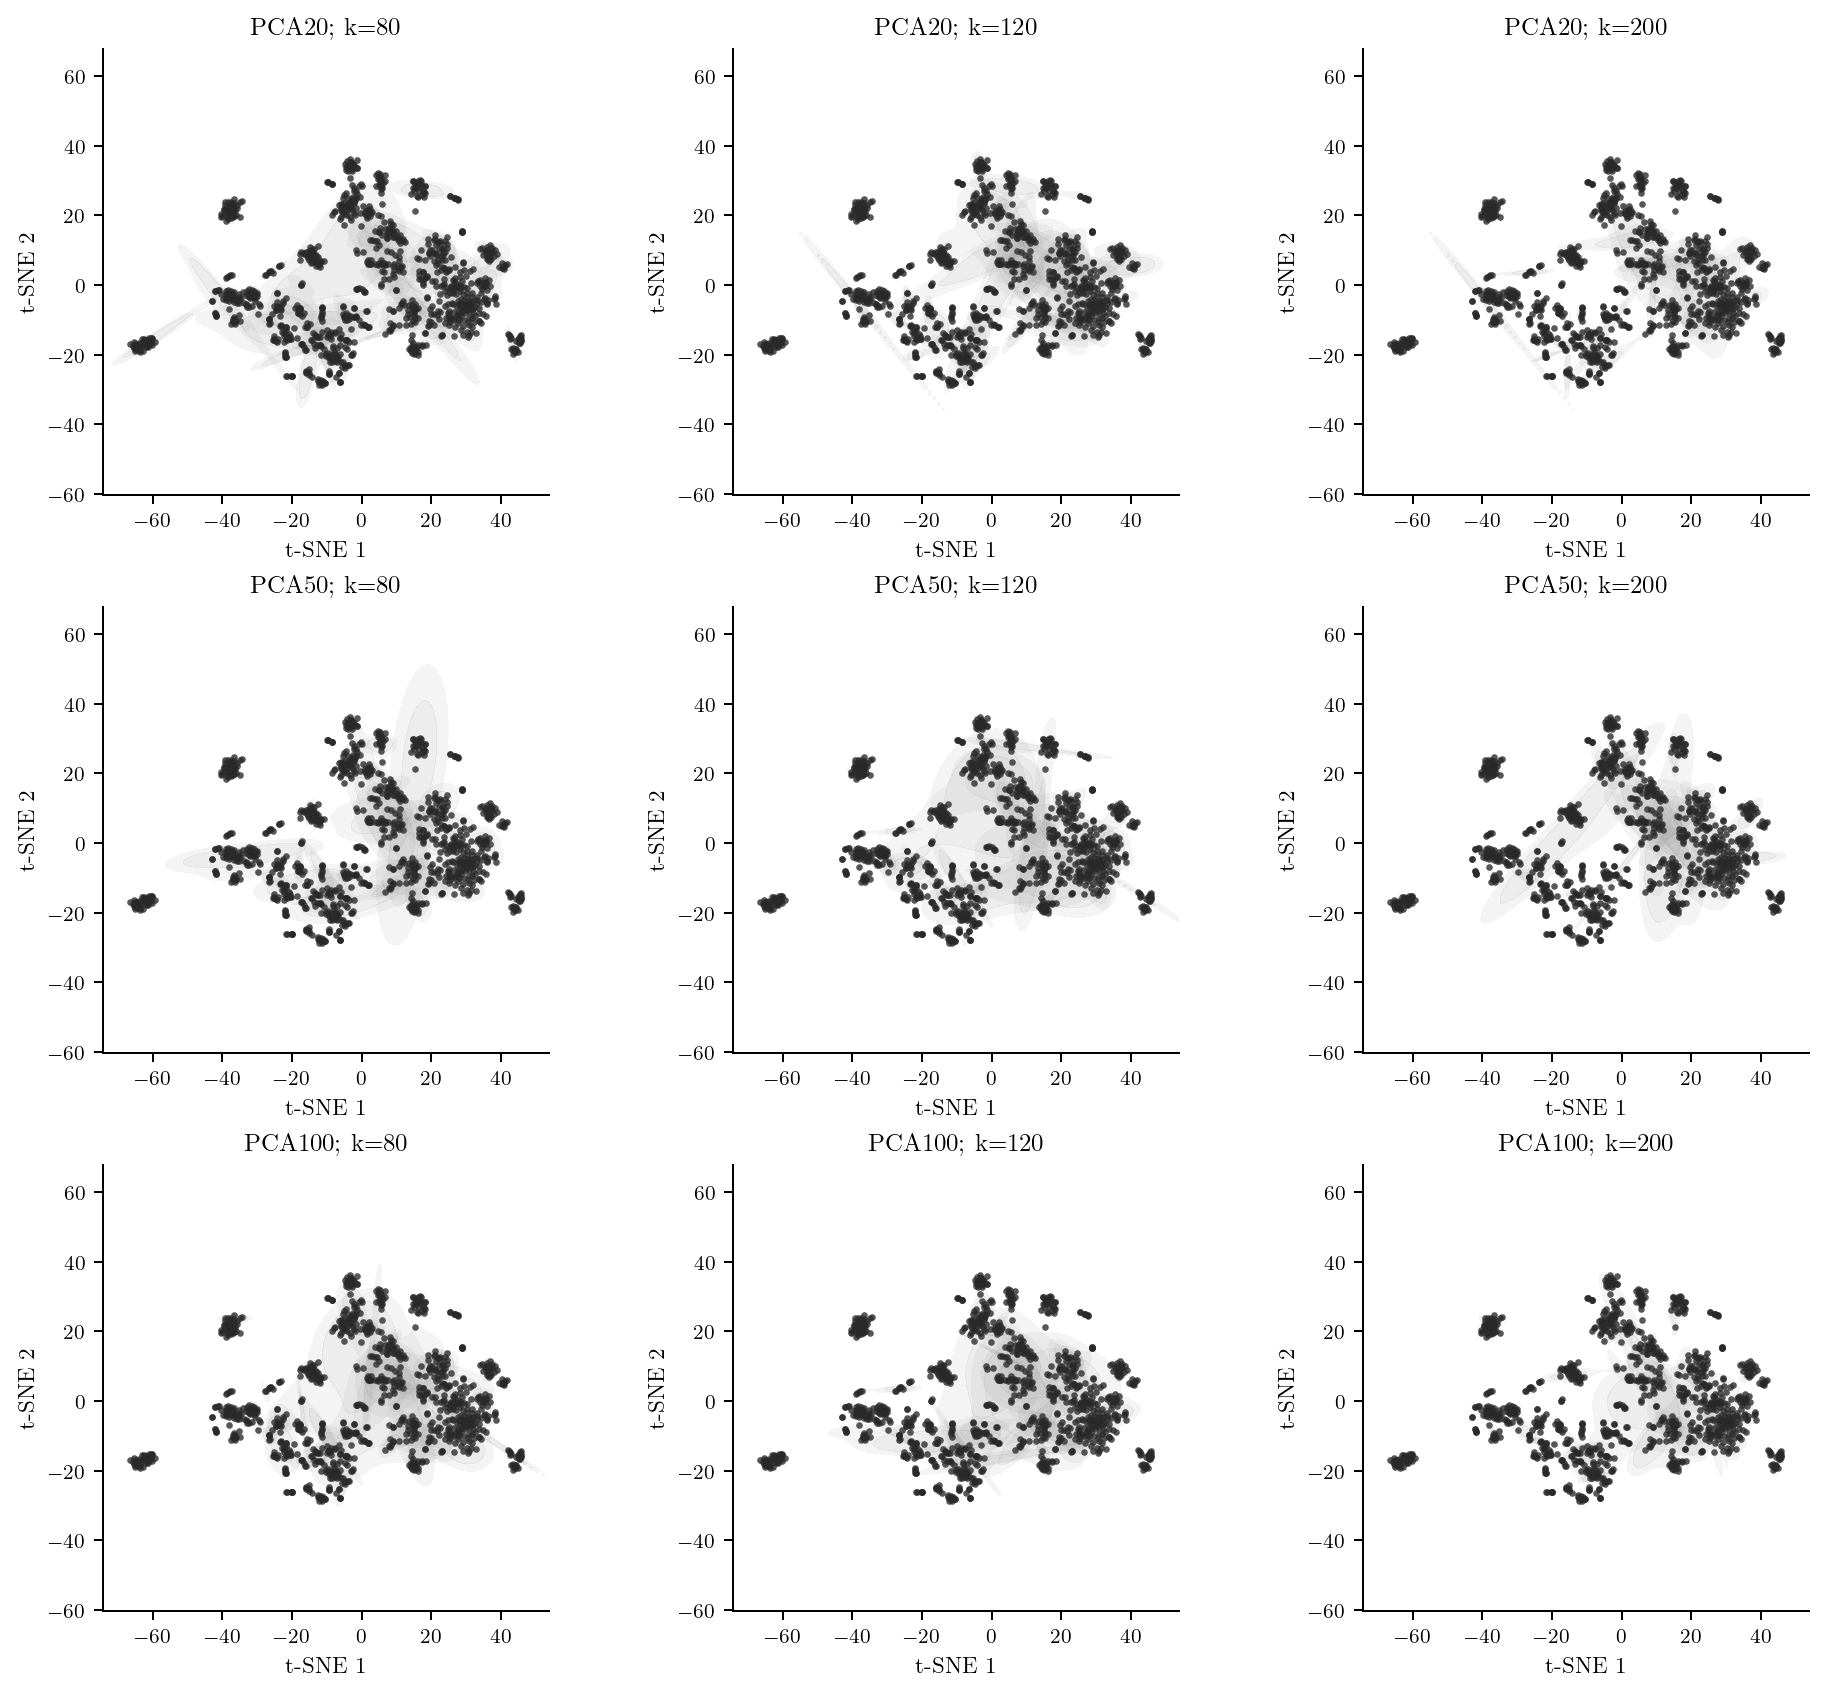

,title,composition,origin,partition,cluster,size,jaccard,full_silhouette,complete_silhouette
0,Foreign-exchange return series,homogeneous,real,kmeans-pca50-k80,25,5,1.000,0.366,0.317
1,BasicMotions walking recordings,homogeneous,real,kmeans-pca100-k80,72,10,1.000,0.166,0.141
2,Two-dimensional wave simulations,homogeneous,synthetic,kmeans-pca20-k40,9,6,1.000,0.369,0.602
3,LEGION oscillator parameter variants,homogeneous,synthetic,kmeans-pca50-k80,33,5,1.000,0.296,0.309
4,Wave-1D and hysteresis-model series,heterogeneous,synthetic,kmeans-pca50-k160,52,5,0.803,0.294,0.155
5,ArticularyWordRecognition and EigenWorms,heterogeneous,real,kmeans-pca100-k160,118,9,0.900,0.167,0.172
6,"Financial levels, Brownian simulations and HCP...",heterogeneous,mixed,kmeans-pca50-k120,81,6,0.695,0.168,0.153


In [12]:
display(Markdown(f'[Open reviewed groups and full member sheets]({(EXPLORE / "shortlist.html").as_uri()})'))
high_k = pd.read_csv(EXPLORE / 'high-k-metrics.csv')
display(high_k[high_k.dimensions.eq(100)][
    ['partition', 'median_size', 'rows_in_under5_fraction', 'subsample_ARI']].round(3))
display(Image(filename=str(EXPLORE / 'figures/high-k-resolutions.png')))
shortlist = pd.read_csv(EXPLORE / 'shortlist.csv')
display(shortlist[['title', 'composition', 'origin', 'partition', 'cluster', 'size', 'jaccard',
                   'full_silhouette', 'complete_silhouette']].round(3))